# Delta-Hedging P&L Lab

**Question:** if you sell an option at implied volatility $\sigma_i$ and delta-hedge it, where does the P&L come from, and what happens when the Black-Scholes assumptions break?

Black-Scholes says a continuously delta-hedged option is riskless. In practice:
- you can only hedge at discrete times,
- the volatility that actually realises ($\sigma_r$) is not the one you sold at ($\sigma_i$),
- every hedge trade costs money.

This notebook measures each of those effects by simulation, then tests the ideas on real BTC data from Deribit.

**The key identity.** Over one small time step, a delta-hedged *short* option earns

$$\text{P\&L}_t \approx \tfrac12\,\Gamma_t S_t^2\left(\sigma_i^2\,\Delta t - \left(\tfrac{\Delta S_t}{S_t}\right)^2\right)$$

You collect theta (the $\sigma_i^2\Delta t$ term) and pay gamma whenever the price actually moves. Summed over the option's life, the seller makes money when realised volatility comes in **below** implied, weighted by dollar gamma $\Gamma S^2$.

**Contents**
1. Black-Scholes core: price, Greeks, implied volatility
2. Sanity checks
3. Simulation engine
4. Experiment 1: hedging frequency
5. Experiment 2: realised vol ≠ implied vol
6. Experiment 3: path dependence
7. Experiment 4: hedging at implied vs realised vol
8. Experiment 5: transaction costs
9. Real data: BTC options on Deribit
10. Summary

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

rng = np.random.default_rng(42)          # fixed seed so every run gives the same numbers
os.makedirs("figures", exist_ok=True)    # charts are saved here for the README
os.makedirs("data", exist_ok=True)       # downloaded market data is cached here

# One consistent colour order for every chart
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948")
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]
GREY = "#8a8985"

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
    "axes.titleweight": "bold", "lines.linewidth": 2, "legend.frameon": False,
})

## 1. Black-Scholes core

Everything is vectorised with NumPy, so the same function prices one option or a million simulated paths at once.

| Greek | Meaning | Formula (call) |
|---|---|---|
| Delta | change in price per \$1 move in $S$ | $N(d_1)$ |
| Gamma | change in delta per \$1 move | $\phi(d_1) / (S\sigma\sqrt{T})$ |
| Vega | change in price per 1.00 (100 vol points) change in $\sigma$ | $S\phi(d_1)\sqrt{T}$ |
| Theta | change in price per year of time passing | $-\frac{S\phi(d_1)\sigma}{2\sqrt T} - rKe^{-rT}N(d_2)$ |

In [2]:
def d1_d2(S, K, T, r, sigma):
    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrtT)
    return d1, d1 - sigma * sqrtT

def bs_price(S, K, T, r, sigma, option="call"):
    d1, d2 = d1_d2(S, K, T, r, sigma)
    if option == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def bs_delta(S, K, T, r, sigma, option="call"):
    d1, _ = d1_d2(S, K, T, r, sigma)
    return norm.cdf(d1) if option == "call" else norm.cdf(d1) - 1.0

def bs_gamma(S, K, T, r, sigma):
    d1, _ = d1_d2(S, K, T, r, sigma)
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))           # same for calls and puts

def bs_vega(S, K, T, r, sigma):
    d1, _ = d1_d2(S, K, T, r, sigma)
    return S * norm.pdf(d1) * np.sqrt(T)                     # same for calls and puts

def bs_theta(S, K, T, r, sigma, option="call"):
    d1, d2 = d1_d2(S, K, T, r, sigma)
    decay = -S * norm.pdf(d1) * sigma / (2 * np.sqrt(T))
    if option == "call":
        return decay - r * K * np.exp(-r * T) * norm.cdf(d2)
    return decay + r * K * np.exp(-r * T) * norm.cdf(-d2)

def implied_vol(price, S, K, T, r, option="call", lo=1e-4, hi=5.0):
    # Brent's method: find the sigma that makes the model price equal the market price.
    # Brent is used instead of Newton because it can't diverge when vega is tiny (deep ITM/OTM).
    f = lambda s: bs_price(S, K, T, r, s, option) - price
    if f(lo) > 0 or f(hi) < 0:
        return np.nan                                        # price outside no-arbitrage bounds
    return brentq(f, lo, hi, xtol=1e-10)

## 2. Sanity checks

Before trusting any experiment, the pricer has to pass four checks:
1. **Put-call parity:** $C - P = S - Ke^{-rT}$ must hold exactly.
2. **Greeks vs finite differences:** each analytic Greek should match a numerical bump of the price.
3. **Implied vol round trip:** price → implied vol → price should give back the original vol.
4. **Monte Carlo:** the average discounted payoff over simulated prices should converge to the formula.

In [3]:
S, K, T, r, sig = 100.0, 105.0, 0.5, 0.03, 0.25
C, P = bs_price(S, K, T, r, sig, "call"), bs_price(S, K, T, r, sig, "put")
checks = []

# 1. Put-call parity
checks.append(("Put-call parity error", C - P - (S - K * np.exp(-r * T)), 1e-10))

# 2. Greeks vs central finite differences
h = 1e-3
fd_delta = (bs_price(S + h, K, T, r, sig) - bs_price(S - h, K, T, r, sig)) / (2 * h)
fd_gamma = (bs_price(S + h, K, T, r, sig) - 2 * C + bs_price(S - h, K, T, r, sig)) / h**2
fd_vega  = (bs_price(S, K, T, r, sig + h) - bs_price(S, K, T, r, sig - h)) / (2 * h)
fd_theta = -(bs_price(S, K, T + h, r, sig) - bs_price(S, K, T - h, r, sig)) / (2 * h)  # theta = -dV/dT
checks.append(("Delta - finite difference", bs_delta(S, K, T, r, sig) - fd_delta, 1e-6))
checks.append(("Gamma - finite difference", bs_gamma(S, K, T, r, sig) - fd_gamma, 1e-4))
checks.append(("Vega - finite difference",  bs_vega(S, K, T, r, sig) - fd_vega, 1e-4))
checks.append(("Theta - finite difference", bs_theta(S, K, T, r, sig) - fd_theta, 1e-4))

# 3. Implied vol round trip across a wide range of vols and strikes.
#    Skip cases with vega < 0.01: there the price is (to machine precision) just
#    intrinsic value or zero, so it carries no information about vol at all.
worst = 0.0
for vol in [0.05, 0.2, 0.5, 1.0, 2.0]:
    for strike in [60, 80, 100, 120, 140]:
        if bs_vega(S, strike, T, r, vol) < 0.01:
            continue
        price = bs_price(S, strike, T, r, vol)
        worst = max(worst, abs(implied_vol(price, S, strike, T, r) - vol))
checks.append(("Implied vol round trip (worst error)", worst, 1e-6))

# 4. Monte Carlo price vs formula
n_mc = 2_000_000
Z = rng.standard_normal(n_mc)
ST = S * np.exp((r - 0.5 * sig**2) * T + sig * np.sqrt(T) * Z)
disc_payoff = np.exp(-r * T) * np.maximum(ST - K, 0)
mc_price, mc_se = disc_payoff.mean(), disc_payoff.std() / np.sqrt(n_mc)
checks.append(("Monte Carlo - formula (in std errors)", (mc_price - C) / mc_se, 3.0))

check_table = pd.DataFrame(checks, columns=["Check", "Error", "Tolerance"])
check_table["Pass"] = check_table["Error"].abs() < check_table["Tolerance"]
print(f"Call = {C:.4f}, Put = {P:.4f}, Monte Carlo call = {mc_price:.4f} ± {mc_se:.4f}\n")
print(check_table.to_string(index=False))
assert check_table["Pass"].all(), "A sanity check failed - fix the pricer before going further"

Call = 5.5760, Put = 9.0127, Monte Carlo call = 5.5795 ± 0.0073

                                Check         Error    Tolerance  Pass
                Put-call parity error -7.105427e-15 1.000000e-10  True
            Delta - finite difference  1.614969e-11 1.000000e-06  True
            Gamma - finite difference  5.067809e-09 1.000000e-04  True
             Vega - finite difference  8.725045e-06 1.000000e-04  True
            Theta - finite difference  2.883372e-06 1.000000e-04  True
 Implied vol round trip (worst error)  2.301453e-11 1.000000e-06  True
Monte Carlo - formula (in std errors)  4.840392e-01 3.000000e+00  True


## 3. Simulation engine

**Price paths.** Geometric Brownian motion with the *realised* volatility $\sigma_r$:
$$S_{t+\Delta t} = S_t \exp\left(\left(\mu - \tfrac12\sigma_r^2\right)\Delta t + \sigma_r\sqrt{\Delta t}\,Z\right)$$

**Hedging strategy.** At time 0 we sell one call for its Black-Scholes price at the *implied* vol $\sigma_i$ and buy $\Delta$ shares. At each rebalancing date we adjust the share holding to the new delta (computed at the *hedging* vol, which is $\sigma_i$ unless stated otherwise). Each trade costs `cost` × the value traded. At expiry we pay the option payoff and sell the remaining shares.

The interest rate is set to 0 in the simulations so the P&L lines up exactly with the gamma formula; the engine itself handles any rate.

In [4]:
def simulate_gbm(S0, mu, sigma, T, n_steps, n_paths, rng):
    # Returns an array of shape (n_paths, n_steps + 1); column 0 is S0.
    dt = T / n_steps
    Z = rng.standard_normal((n_paths, n_steps))
    log_steps = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.concatenate([np.zeros((n_paths, 1)), np.cumsum(log_steps, axis=1)], axis=1)
    return S0 * np.exp(log_paths)

def delta_hedge_pnl(paths, K, T, r, sigma_implied, sigma_hedge=None, cost=0.0,
                    option="call", track=False):
    # Short one option sold at sigma_implied, delta-hedged at every column of `paths`.
    # Returns final P&L per path; with track=True also the mark-to-market P&L at every date.
    if sigma_hedge is None:
        sigma_hedge = sigma_implied
    n_paths, n_cols = paths.shape
    n_steps = n_cols - 1
    dt = T / n_steps
    growth = np.exp(r * dt)

    S = paths[:, 0]
    premium = bs_price(S, K, T, r, sigma_implied, option)
    delta = bs_delta(S, K, T, r, sigma_hedge, option)
    fees = cost * np.abs(delta) * S
    cash = premium - delta * S - fees
    total_fees = fees.copy()
    mtm = [np.zeros(n_paths)] if track else None

    for i in range(1, n_steps):
        S = paths[:, i]
        tau = T - i * dt                                   # time left to expiry
        cash = cash * growth
        new_delta = bs_delta(S, K, tau, r, sigma_hedge, option)
        trade = new_delta - delta
        fees = cost * np.abs(trade) * S
        cash -= trade * S + fees
        total_fees += fees
        delta = new_delta
        if track:   # portfolio value minus the option's fair value at the implied vol
            mtm.append(cash + delta * S - bs_price(S, K, tau, r, sigma_implied, option))

    S_T = paths[:, -1]
    cash = cash * growth
    payoff = np.maximum(S_T - K, 0) if option == "call" else np.maximum(K - S_T, 0)
    fees = cost * np.abs(delta) * S_T                      # unwind the hedge at expiry
    pnl = cash + delta * S_T - fees - payoff
    total_fees += fees
    out = {"pnl": pnl, "premium": premium, "fees": total_fees}
    if track:
        mtm.append(pnl)
        out["mtm"] = np.column_stack(mtm)
    return out

def gamma_pnl_prediction(paths, K, T, sigma_implied):
    # Sum of 1/2 * Gamma * S^2 * (sigma_i^2 dt - return^2) along each path (r = 0, short option).
    n_steps = paths.shape[1] - 1
    dt = T / n_steps
    pred = np.zeros(paths.shape[0])
    for i in range(n_steps):
        S = paths[:, i]
        gamma = bs_gamma(S, K, T - i * dt, 0.0, sigma_implied)
        ret = paths[:, i + 1] / S - 1
        pred += 0.5 * gamma * S**2 * (sigma_implied**2 * dt - ret**2)
    return pred

def realised_vol(paths, T):
    log_ret = np.diff(np.log(paths), axis=1)
    return np.sqrt((log_ret**2).sum(axis=1) / T)

## 4. Experiment 1: how often do you need to hedge?

Set realised vol equal to implied vol (20%), so in continuous time the hedge would be perfect. With discrete hedging there is leftover noise. Theory (Derman & Kamal, 1999) says its standard deviation shrinks like $1/\sqrt{N}$:

$$\text{std}(\text{P\&L}) \approx \sqrt{\frac{\pi}{4}}\;\frac{\sigma\cdot\text{vega}}{\sqrt N}$$

All frequencies use the same simulated paths (sampled more or less often), so the comparison is fair.

In [5]:
S0, K, T, r, sigma = 100.0, 100.0, 0.25, 0.0, 0.20     # 3-month at-the-money call
N_FINE, N_PATHS = 2000, 4000
fine_paths = simulate_gbm(S0, 0.0, sigma, T, N_FINE, N_PATHS, rng)
premium = bs_price(S0, K, T, r, sigma)
vega = bs_vega(S0, K, T, r, sigma)

rows = []
for N in [10, 20, 50, 100, 250, 500, 1000, 2000]:
    paths_N = fine_paths[:, :: N_FINE // N]            # hedge N times over the option's life
    pnl = delta_hedge_pnl(paths_N, K, T, r, sigma)["pnl"]
    rows.append({"N hedges": N, "mean P&L": pnl.mean(), "std P&L": pnl.std(),
                 "Derman-Kamal std": np.sqrt(np.pi / 4) * sigma * vega / np.sqrt(N)})
freq = pd.DataFrame(rows)
freq["std / premium"] = freq["std P&L"] / premium
freq["actual / theory"] = freq["std P&L"] / freq["Derman-Kamal std"]

slope = np.polyfit(np.log(freq["N hedges"]), np.log(freq["std P&L"]), 1)[0]
print(f"Option premium: {premium:.3f}   Vega: {vega:.2f}")
print(f"Fitted log-log slope: {slope:.3f}   (theory: -0.5)\n")
print(freq.round(4).to_string(index=False))

Option premium: 3.988   Vega: 19.92
Fitted log-log slope: -0.487   (theory: -0.5)

 N hedges  mean P&L  std P&L  Derman-Kamal std  std / premium  actual / theory
       10   -0.0060   1.0325            1.1166         0.2589           0.9246
       20   -0.0154   0.7500            0.7896         0.1881           0.9499
       50    0.0015   0.4854            0.4994         0.1217           0.9720
      100   -0.0006   0.3442            0.3531         0.0863           0.9747
      250    0.0034   0.2166            0.2233         0.0543           0.9698
      500   -0.0008   0.1560            0.1579         0.0391           0.9881
     1000   -0.0008   0.1115            0.1117         0.0280           0.9984
     2000    0.0012   0.0790            0.0790         0.0198           1.0007


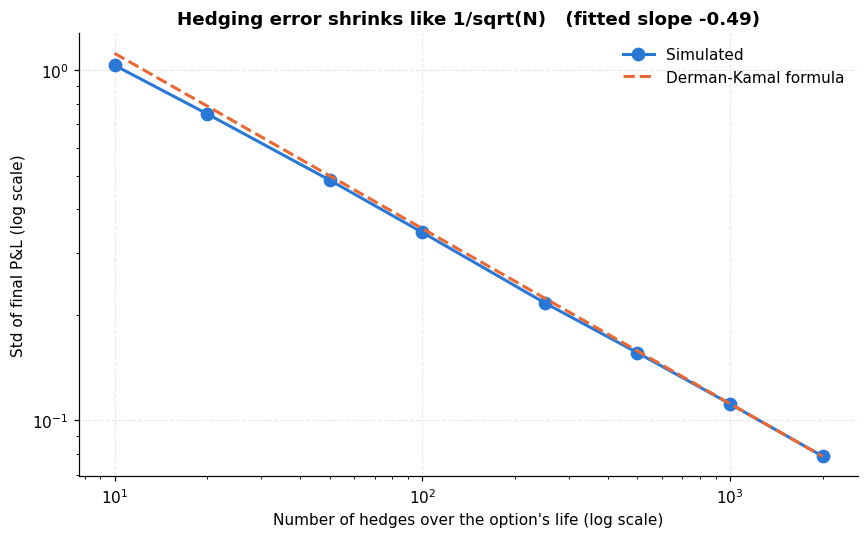

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(freq["N hedges"], freq["std P&L"], "o-", color=BLUE, markersize=8, label="Simulated")
ax.loglog(freq["N hedges"], freq["Derman-Kamal std"], "--", color=ORANGE, label="Derman-Kamal formula")
ax.set_xlabel("Number of hedges over the option's life (log scale)")
ax.set_ylabel("Std of final P&L (log scale)")
ax.set_title(f"Hedging error shrinks like 1/sqrt(N)   (fitted slope {slope:.2f})")
ax.legend()
plt.tight_layout(); plt.savefig("figures/01_hedge_frequency.png", bbox_inches="tight"); plt.show()

**What to notice.** Quadrupling the number of hedges only halves the error, because the error scales with $1/\sqrt N$, not $1/N$. That is why traders don't hedge continuously: past a point, the extra trades buy very little risk reduction (and Experiment 5 shows they cost real money).

## 5. Experiment 2: realised vol ≠ implied vol

Now the option is sold at 20% implied vol, but the market realises 10% to 30%. The hedge runs daily (63 hedges over 3 months), always at the implied vol.

If the seller hedges at implied vol, their expected P&L is roughly the difference in option values, $C(\sigma_i) - C(\sigma_r)$. The second check is the core identity: does the gamma formula, computed path by path, predict each path's actual P&L?

In [7]:
N_DAILY, N_PATHS = 63, 4000
sigma_i = 0.20
mismatch_rows, stored = [], {}
for sigma_r in [0.10, 0.15, 0.20, 0.25, 0.30]:
    paths = simulate_gbm(S0, 0.0, sigma_r, T, N_DAILY, N_PATHS, rng)
    pnl = delta_hedge_pnl(paths, K, T, r, sigma_i)["pnl"]
    pred = gamma_pnl_prediction(paths, K, T, sigma_i)
    stored[sigma_r] = (paths, pnl, pred)
    mismatch_rows.append({
        "realised vol": sigma_r, "mean P&L": pnl.mean(), "std P&L": pnl.std(),
        "C(sigma_i) - C(sigma_r)": premium - bs_price(S0, K, T, r, sigma_r),
        "% paths profitable": 100 * (pnl > 0).mean(),
        "corr(P&L, gamma formula)": np.corrcoef(pnl, pred)[0, 1]})
mismatch = pd.DataFrame(mismatch_rows)
print(mismatch.round(4).to_string(index=False))

 realised vol  mean P&L  std P&L  C(sigma_i) - C(sigma_r)  % paths profitable  corr(P&L, gamma formula)
         0.10    2.0054   0.5387                   1.9933             100.000                    0.9899
         0.15    0.9942   0.4565                   0.9964              99.775                    0.9892
         0.20    0.0039   0.4330                   0.0000              51.650                    0.9817
         0.25   -1.0130   0.7028                  -0.9958               2.550                    0.9805
         0.30   -1.9908   1.1171                  -1.9908               0.025                    0.9840


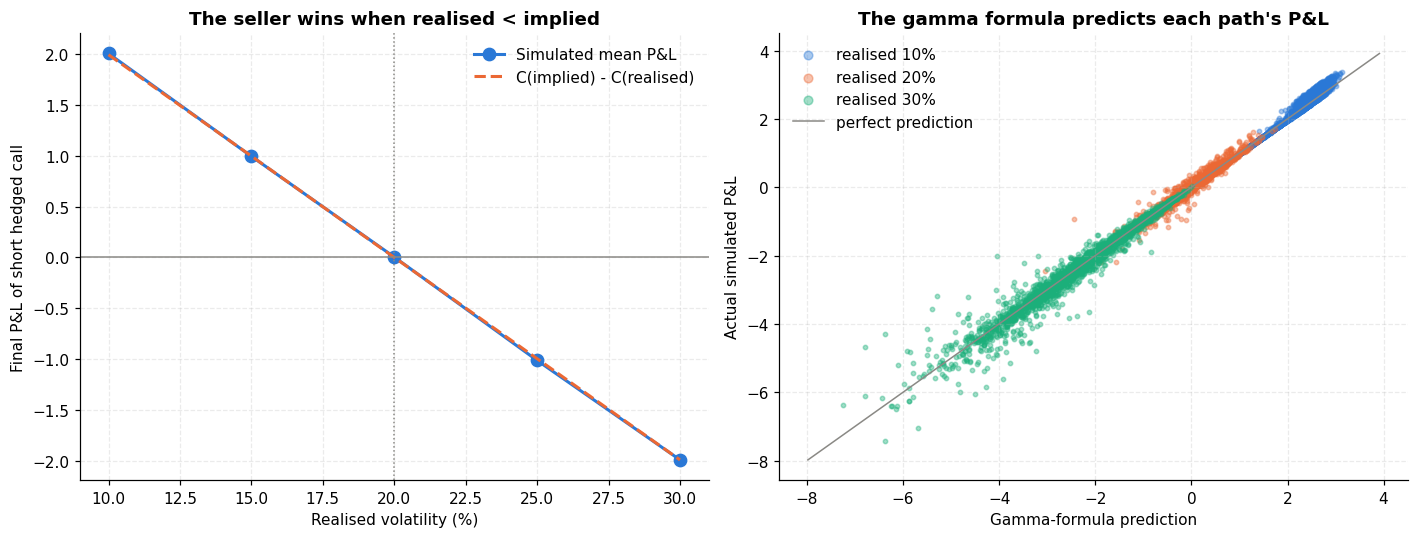

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(mismatch["realised vol"] * 100, mismatch["mean P&L"], "o-", color=BLUE, markersize=8,
        label="Simulated mean P&L")
ax.plot(mismatch["realised vol"] * 100, mismatch["C(sigma_i) - C(sigma_r)"], "--", color=ORANGE,
        label="C(implied) - C(realised)")
ax.axhline(0, color=GREY, linewidth=1)
ax.axvline(sigma_i * 100, color=GREY, linestyle=":", linewidth=1)
ax.set_xlabel("Realised volatility (%)")
ax.set_ylabel("Final P&L of short hedged call")
ax.set_title("The seller wins when realised < implied")
ax.legend()

ax = axes[1]
for (sigma_r, colour) in zip([0.10, 0.20, 0.30], [BLUE, ORANGE, AQUA]):
    _, pnl, pred = stored[sigma_r]
    ax.scatter(pred, pnl, s=8, alpha=0.4, color=colour, label=f"realised {sigma_r:.0%}")
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, color=GREY, linewidth=1, label="perfect prediction")
ax.set_xlabel("Gamma-formula prediction")
ax.set_ylabel("Actual simulated P&L")
ax.set_title("The gamma formula predicts each path's P&L")
ax.legend(markerscale=2)
plt.tight_layout(); plt.savefig("figures/02_vol_mismatch.png", bbox_inches="tight"); plt.show()

**What to notice.** The left chart is the trade in one picture: selling options is a bet that realised vol comes in below implied. The right chart shows the P&L is not luck. The gamma identity explains nearly all of each path's result; what's left is the discrete-hedging noise from Experiment 1.

## 6. Experiment 3: same volatility, different P&L

The gamma formula weights each day's move by $\Gamma S^2$, and gamma is largest **near the strike and close to expiry**. So two paths with exactly the same realised volatility can produce very different P&L, depending on *where* the big moves happened.

Below: from the paths where realised vol matched implied (20%), pick the two with realised vol within 0.25 vol points of each other whose P&L differs the most.

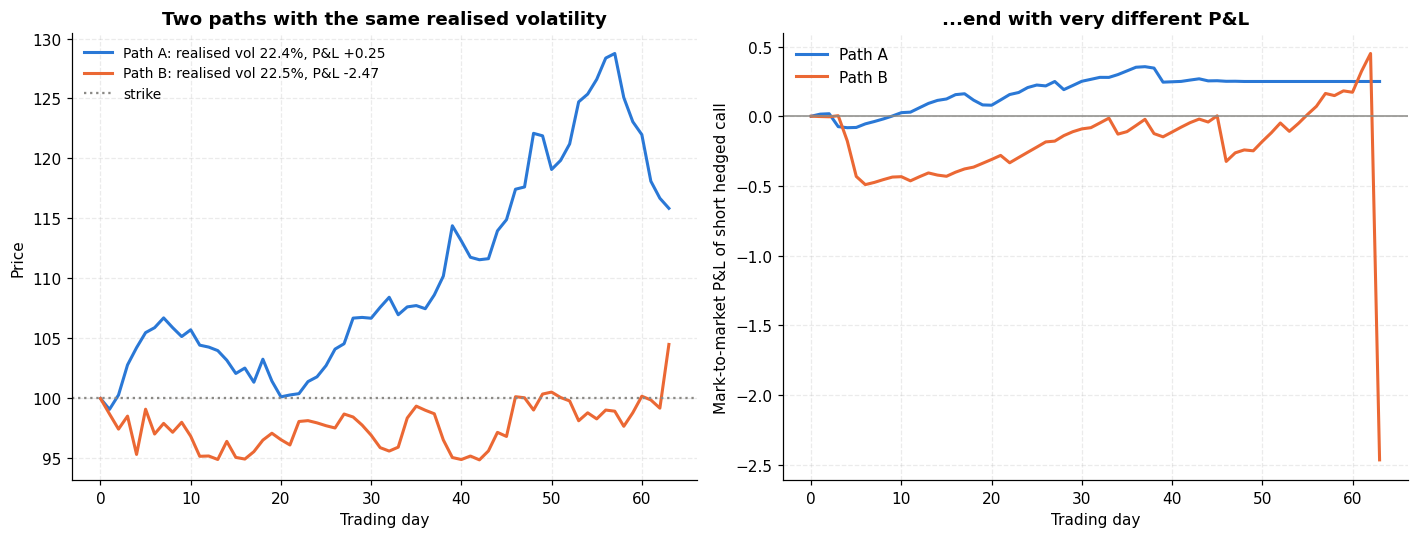

Path A: realised vol 22.36%, final P&L +0.249
Path B: realised vol 22.46%, final P&L -2.465


In [9]:
paths_20, pnl_20, _ = stored[0.20]
rv = realised_vol(paths_20, T)
order = np.argsort(rv)
best = (0, 0, -1.0)
for a_pos in range(len(order)):                       # scan pairs with near-identical realised vol
    a = order[a_pos]
    b_pos = a_pos + 1
    while b_pos < len(order) and rv[order[b_pos]] - rv[a] < 0.0025:
        b = order[b_pos]
        gap = abs(pnl_20[a] - pnl_20[b])
        if gap > best[2]:
            best = (a, b, gap)
        b_pos += 1
a, b, _ = best
winner, loser = (a, b) if pnl_20[a] > pnl_20[b] else (b, a)

mtm = delta_hedge_pnl(paths_20[[winner, loser]], K, T, r, sigma_i, track=True)["mtm"]
days = np.arange(N_DAILY + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for idx, (path_id, colour, name) in enumerate([(winner, BLUE, "Path A"), (loser, ORANGE, "Path B")]):
    label = f"{name}: realised vol {rv[path_id]:.1%}, P&L {pnl_20[path_id]:+.2f}"
    axes[0].plot(days, paths_20[path_id], color=colour, label=label)
    axes[1].plot(days, mtm[idx], color=colour, label=name)
axes[0].axhline(K, color=GREY, linestyle=":", linewidth=1.5, label="strike")
axes[0].set_xlabel("Trading day"); axes[0].set_ylabel("Price")
axes[0].set_title("Two paths with the same realised volatility")
axes[0].legend(fontsize=9)
axes[1].axhline(0, color=GREY, linewidth=1)
axes[1].set_xlabel("Trading day"); axes[1].set_ylabel("Mark-to-market P&L of short hedged call")
axes[1].set_title("...end with very different P&L")
axes[1].legend()
plt.tight_layout(); plt.savefig("figures/03_path_dependence.png", bbox_inches="tight"); plt.show()

print(f"Path A: realised vol {rv[winner]:.2%}, final P&L {pnl_20[winner]:+.3f}")
print(f"Path B: realised vol {rv[loser]:.2%}, final P&L {pnl_20[loser]:+.3f}")

**What to notice.** Look at where each path sits relative to the strike line late in the option's life. The path that wanders around the strike near expiry pays a lot of gamma; the path that moves away from the strike early makes its big moves where gamma is small. Same volatility, different outcome. This is why "I sold vol and realised came in lower" doesn't guarantee a profit.

## 7. Experiment 4: hedge at implied vol or at realised vol?

Suppose you somehow knew the true realised vol (30%) when you sold at 20%. Which vol should you put into the delta? We hedge 1,000 times here so that discrete-hedging noise (Experiment 1) doesn't blur the comparison; try `N_EXP4 = 63` to see how daily hedging muddies it. (Ahmad & Wilmott, *"Which free lunch would you like today, sir?"*, 2005.)

- **Hedge at realised vol:** the final P&L is (almost) locked in at $C(\sigma_i) - C(\sigma_r)$ on every path, but the mark-to-market swings around during the trade.
- **Hedge at implied vol:** the mark-to-market moves smoothly, but the final P&L depends on the path.

Theoretical locked-in P&L, C(20%) - C(30%) = -1.991

      Hedge at  mean final P&L  std final P&L  avg daily MTM change
 implied (20%)         -1.9953         0.9344                0.0302
realised (30%)         -1.9914         0.1646                0.0789


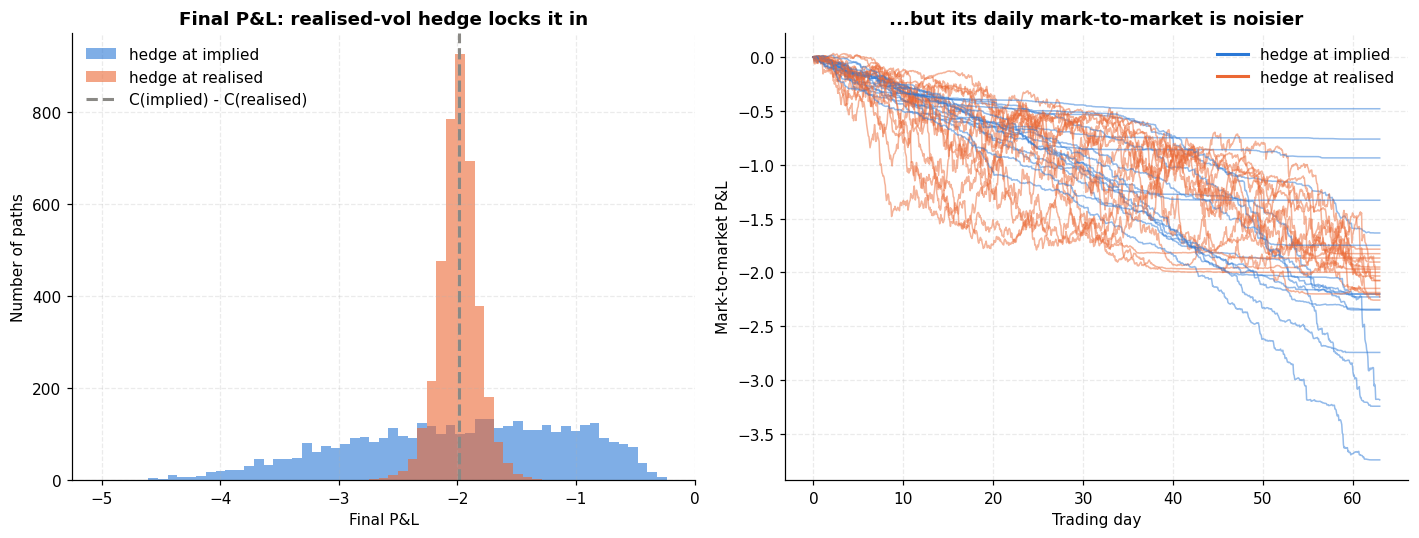

In [10]:
sigma_r = 0.30
N_EXP4 = 1000   # hedge often, so discrete-hedging noise doesn't hide the effect
paths = simulate_gbm(S0, 0.0, sigma_r, T, N_EXP4, N_PATHS, rng)
at_implied = delta_hedge_pnl(paths, K, T, r, sigma_i, sigma_hedge=sigma_i, track=True)
at_realised = delta_hedge_pnl(paths, K, T, r, sigma_i, sigma_hedge=sigma_r, track=True)
locked_in = premium - bs_price(S0, K, T, r, sigma_r)

def mtm_noise(m):   # average wobble of the mark-to-market P&L per trading day (every 1000/63 steps)
    daily = m[:, :: N_EXP4 // N_DAILY]
    return np.abs(np.diff(daily, axis=1)).mean()

hedge_choice = pd.DataFrame({
    "Hedge at": ["implied (20%)", "realised (30%)"],
    "mean final P&L": [at_implied["pnl"].mean(), at_realised["pnl"].mean()],
    "std final P&L": [at_implied["pnl"].std(), at_realised["pnl"].std()],
    "avg daily MTM change": [mtm_noise(at_implied["mtm"]), mtm_noise(at_realised["mtm"])]})
print(f"Theoretical locked-in P&L, C(20%) - C(30%) = {locked_in:.3f}\n")
print(hedge_choice.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bins = np.linspace(min(at_implied["pnl"].min(), at_realised["pnl"].min()),
                   max(at_implied["pnl"].max(), at_realised["pnl"].max()), 60)
axes[0].hist(at_implied["pnl"], bins=bins, color=BLUE, alpha=0.6, label="hedge at implied")
axes[0].hist(at_realised["pnl"], bins=bins, color=ORANGE, alpha=0.6, label="hedge at realised")
axes[0].axvline(locked_in, color=GREY, linestyle="--", label="C(implied) - C(realised)")
axes[0].set_xlabel("Final P&L"); axes[0].set_ylabel("Number of paths")
axes[0].set_title("Final P&L: realised-vol hedge locks it in")
axes[0].legend()
for i in range(15):
    days = np.linspace(0, N_DAILY, N_EXP4 + 1)
    axes[1].plot(days, at_implied["mtm"][i], color=BLUE, alpha=0.5, linewidth=1)
    axes[1].plot(days, at_realised["mtm"][i], color=ORANGE, alpha=0.5, linewidth=1)
axes[1].plot([], [], color=BLUE, label="hedge at implied")
axes[1].plot([], [], color=ORANGE, label="hedge at realised")
axes[1].set_xlabel("Trading day"); axes[1].set_ylabel("Mark-to-market P&L")
axes[1].set_title("...but its daily mark-to-market is noisier")
axes[1].legend()
plt.tight_layout(); plt.savefig("figures/04_hedge_vol_choice.png", bbox_inches="tight"); plt.show()

**What to notice.** There's no free lunch, only a choice of which risk to carry. A trader marked to market daily (with a risk manager watching) usually prefers the smooth path; someone who can hold to expiry and is confident in their vol forecast might prefer the locked-in outcome. In practice you never know realised vol in advance, which makes hedging at implied the default.

## 8. Experiment 5: transaction costs and the optimal hedging frequency

Every rebalance now costs a fraction of the value traded (0, 5, 10 or 20 basis points, one way). More frequent hedging means less hedging noise but more fees. The quantity to minimise is the total error of the hedge around zero:
$$\text{RMSE} = \sqrt{\text{mean}^2 + \text{std}^2}$$

**Leland (1985)** showed the seller can cover expected costs by pricing and hedging at an adjusted vol, where $k$ is the round-trip cost (twice the one-way cost):
$$\sigma_L^2 = \sigma^2\left(1 + \sqrt{\tfrac{2}{\pi}}\,\frac{k}{\sigma\sqrt{\Delta t}}\right)$$

Optimal number of hedges for each cost level:

 cost (bp)  N hedges   RMSE  avg fees
         0      2000 0.0790    0.0000
         5       250 0.3827    0.3027
        10       100 0.5674    0.4203
        20        50 0.8459    0.6520


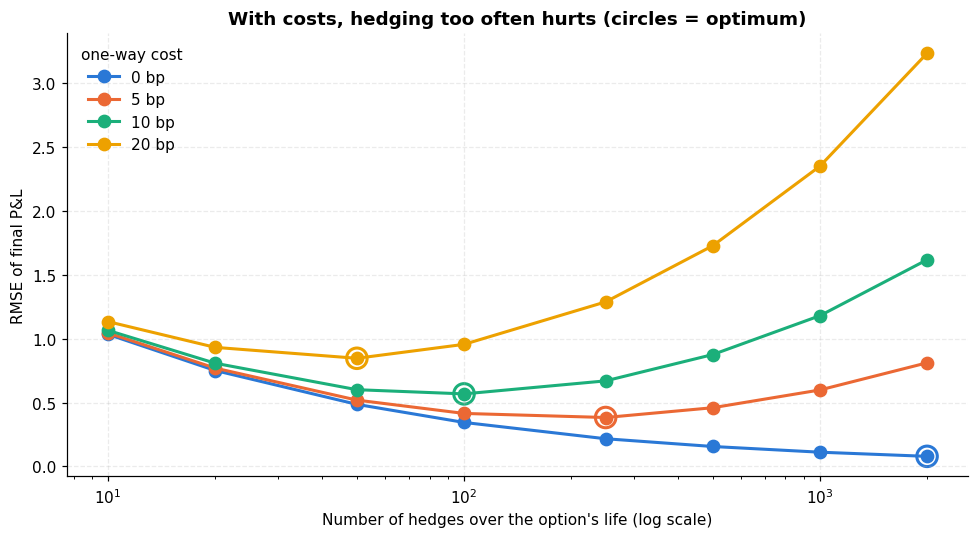

In [11]:
costs_bp = [0, 5, 10, 20]
freqs = [10, 20, 50, 100, 250, 500, 1000, 2000]
cost_rows = []
for c_bp in costs_bp:
    for N in freqs:
        out = delta_hedge_pnl(fine_paths[:, :: N_FINE // N], K, T, r, sigma, cost=c_bp / 1e4)
        pnl = out["pnl"]
        cost_rows.append({"cost (bp)": c_bp, "N hedges": N, "mean P&L": pnl.mean(),
                          "std P&L": pnl.std(), "avg fees": out["fees"].mean(),
                          "RMSE": np.sqrt(np.mean(pnl**2))})
cost_table = pd.DataFrame(cost_rows)
best_n = cost_table.loc[cost_table.groupby("cost (bp)")["RMSE"].idxmin(), ["cost (bp)", "N hedges", "RMSE", "avg fees"]]
print("Optimal number of hedges for each cost level:\n")
print(best_n.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
for c_bp, colour in zip(costs_bp, SERIES):
    sub = cost_table[cost_table["cost (bp)"] == c_bp]
    ax.plot(sub["N hedges"], sub["RMSE"], "o-", color=colour, markersize=8, label=f"{c_bp} bp")
    opt = sub.loc[sub["RMSE"].idxmin()]
    ax.scatter(opt["N hedges"], opt["RMSE"], s=180, facecolors="none", edgecolors=colour, linewidths=2)
ax.set_xscale("log")
ax.set_xlabel("Number of hedges over the option's life (log scale)")
ax.set_ylabel("RMSE of final P&L")
ax.set_title("With costs, hedging too often hurts (circles = optimum)")
ax.legend(title="one-way cost")
plt.tight_layout(); plt.savefig("figures/05_transaction_costs.png", bbox_inches="tight"); plt.show()

In [12]:
# Leland check: daily hedging (63 hedges) with 10bp one-way costs
c, N = 0.0010, 63
dt = T / N
paths_63 = simulate_gbm(S0, 0.0, sigma, T, N, N_PATHS, rng)
sigma_L = sigma * np.sqrt(1 + np.sqrt(2 / np.pi) * (2 * c) / (sigma * np.sqrt(dt)))

plain = delta_hedge_pnl(paths_63, K, T, r, sigma, cost=c)["pnl"]
leland = delta_hedge_pnl(paths_63, K, T, r, sigma_L, cost=c)["pnl"]

# Leland only covers the costs of *rebalancing*. The first delta purchase and the
# final unwind are one-off costs on top, so estimate them separately:
d0 = bs_delta(S0, K, T, r, sigma_L)
setup_unwind = c * d0 * S0 + c * np.mean(paths_63[:, -1] * (paths_63[:, -1] > K))

leland_table = pd.DataFrame({
    "Priced and hedged at": [f"Black-Scholes vol {sigma:.1%}", f"Leland vol {sigma_L:.2%}"],
    "premium": [premium, bs_price(S0, K, T, r, sigma_L)],
    "mean P&L": [plain.mean(), leland.mean()], "std P&L": [plain.std(), leland.std()]})
print(leland_table.round(4).to_string(index=False))
print(f"\nSet-up + unwind fees (not covered by Leland): {setup_unwind:.4f}")
print(f"Leland mean P&L after adding those back:      {leland.mean() + setup_unwind:.4f}")

   Priced and hedged at  premium  mean P&L  std P&L
Black-Scholes vol 20.0%   3.9878   -0.3544   0.4591
      Leland vol 21.23%   4.2326   -0.1016   0.4514

Set-up + unwind fees (not covered by Leland): 0.1037
Leland mean P&L after adding those back:      0.0021


**What to notice.** Without costs, more hedging is always better. With costs, each line bottoms out and then rises: past the optimum you are paying fees to remove noise that is smaller than the fees. The higher the cost, the less often you should hedge. Leland's adjustment shows the fix on the pricing side: charge a slightly higher vol, and the expected cost of *rebalancing* is covered. What's left over is the one-off cost of buying the initial delta and unwinding at expiry, which the formula ignores by design.

## 9. Real data: selling BTC options on Deribit

Now the same strategy on real prices. Deribit is the largest crypto options exchange, and its public API is free and needs no account.

**Data (daily, from Deribit's public API):**
- **DVOL:** Deribit's 30-day implied volatility index for BTC (think of it as the VIX of bitcoin), used as the implied vol of a 30-day at-the-money option.
- **BTC-PERPETUAL closing prices:** used to hedge and to measure realised vol.

**Backtest:** every 7 days, sell a 30-day at-the-money call priced at DVOL, delta-hedge it daily at that implied vol, pay 5 bp per hedge trade, and hold to expiry. P&L is reported as a % of the BTC price at the start.

**Limitations (worth stating in the README):**
- DVOL is a constant-maturity index built from options across many strikes (like the VIX), so it includes the skew and usually sits *above* at-the-money implied vol. Using it as the ATM vol overstates the premium you would really collect.
- The option's bid-ask spread is handled with a simple sensitivity test (below), not real quotes. Funding costs on the perpetual are ignored.
- The sample (roughly the last 3 years) may not contain a crash as violent as 2020 or 2022, so the tail risk is probably understated.
- Crypto trades every day, so vols are annualised with 365 days.

The first run downloads the data and saves it to `data/`; later runs read the saved file.

In [18]:
import requests

DERIBIT = "https://www.deribit.com/api/v2/public/"
CACHE = "data/deribit_btc_daily.csv"
DAY_MS = 86_400_000

def deribit_get(method, params):
    resp = requests.get(DERIBIT + method, params=params, timeout=30)
    resp.raise_for_status()
    return resp.json()["result"]

def fetch_dvol(start_ms, end_ms):
    # The endpoint returns a limited number of points per call, so walk backwards in time
    # using the 'continuation' timestamp it hands back.
    rows, end = [], end_ms
    while True:
        res = deribit_get("get_volatility_index_data", {
            "currency": "BTC", "start_timestamp": start_ms, "end_timestamp": end, "resolution": "1D"})
        rows += res["data"]
        cont = res.get("continuation")
        if not cont or cont <= start_ms or cont >= end:
            break
        end = cont
        time.sleep(0.2)                                    # be polite to the API
    df = pd.DataFrame(rows, columns=["ts", "open", "high", "low", "close"]).drop_duplicates("ts")
    df["date"] = pd.to_datetime(df["ts"], unit="ms").dt.normalize()
    return df[["date", "close"]].rename(columns={"close": "dvol"})

def fetch_perp_closes(start_ms, end_ms):
    # Download in one-year chunks to stay inside the API's per-request limit.
    frames, chunk_start = [], start_ms
    while chunk_start < end_ms:
        chunk_end = min(chunk_start + 365 * DAY_MS, end_ms)
        res = deribit_get("get_tradingview_chart_data", {
            "instrument_name": "BTC-PERPETUAL", "start_timestamp": chunk_start,
            "end_timestamp": chunk_end, "resolution": "1D"})
        if res.get("status") == "ok":
            frames.append(pd.DataFrame({"ts": res["ticks"], "spot": res["close"]}))
        chunk_start = chunk_end + 1
        time.sleep(0.2)
    df = pd.concat(frames).drop_duplicates("ts")
    df["date"] = pd.to_datetime(df["ts"], unit="ms").dt.normalize()
    return df[["date", "spot"]]

def load_btc_data(years=3, refresh=False):
    if os.path.exists(CACHE) and not refresh:
        return pd.read_csv(CACHE, parse_dates=["date"])
    end_ms = int(time.time() * 1000)
    start_ms = end_ms - years * 365 * DAY_MS
    df = fetch_perp_closes(start_ms, end_ms).merge(fetch_dvol(start_ms, end_ms), on="date", how="inner")
    df = df.sort_values("date").reset_index(drop=True)
    df.to_csv(CACHE, index=False)
    return df

try:
    btc = load_btc_data(years=3)
    print(f"Loaded {len(btc)} days: {btc['date'].iloc[0].date()} to {btc['date'].iloc[-1].date()}")
    print(btc.tail())
except Exception as err:
    btc = None
    print(f"Could not download Deribit data ({err}).\n"
          "Check your internet connection and rerun this cell; the sections below are skipped until it works.")

Loaded 1096 days: 2023-10-09 to 2026-10-08
           date     spot   dvol
1091 2026-10-04  86259.5  36.50
1092 2026-10-05  85553.0  36.10
1093 2026-10-06  84121.0  36.13
1094 2026-10-07  82968.0  36.76
1095 2026-10-08  82582.5  38.82


In [14]:
def backtest_short_atm(df, tenor_days=30, step_days=7, cost=0.0005):
    results = []
    T_opt = tenor_days / 365
    for start in range(0, len(df) - tenor_days, step_days):
        window = df.iloc[start:start + tenor_days + 1]
        S_path = window["spot"].to_numpy()[None, :]           # one path, hedged once a day
        iv = window["dvol"].iloc[0] / 100
        strike = S_path[0, 0]                                 # at the money
        out = delta_hedge_pnl(S_path, strike, T_opt, 0.0, iv, cost=cost)
        rv = realised_vol(S_path, T_opt)[0]
        results.append({"date": window["date"].iloc[0], "implied vol": iv, "realised vol": rv,
                        "vol premium": iv - rv,
                        "premium %": 100 * out["premium"][0] / strike,
                        "vega % per vol pt": bs_vega(strike, strike, T_opt, 0.0, iv) / strike,
                        "P&L %": 100 * out["pnl"][0] / strike,
                        "gamma formula %": 100 * gamma_pnl_prediction(S_path, strike, T_opt, iv)[0] / strike})
    return pd.DataFrame(results)

if btc is not None:
    # Realised vol over the NEXT 30 days, so it covers the same window as today's implied vol
    btc["rv_next_30d"] = np.sqrt(365 * (np.log(btc["spot"]).diff() ** 2).rolling(30).mean()).shift(-30)
    trades = backtest_short_atm(btc)
    summary = pd.Series({
        "trades": len(trades),
        "average implied vol": trades["implied vol"].mean(),
        "average realised vol": trades["realised vol"].mean(),
        "% of trades where implied > realised": 100 * (trades["vol premium"] > 0).mean(),
        "average P&L (% of spot)": trades["P&L %"].mean(),
        "% of trades profitable": 100 * (trades["P&L %"] > 0).mean(),
        "worst trade (% of spot)": trades["P&L %"].min(),
        "corr(P&L, gamma formula)": trades[["P&L %", "gamma formula %"]].corr().iloc[0, 1]})
    print(summary.round(3).to_string())

    # Bid-ask spread: selling below mid costs roughly vega x (vol points given up)
    spread_rows = []
    for give_up in [0, 0.5, 1, 2, 3]:
        pnl_net = trades["P&L %"] - trades["vega % per vol pt"] * give_up
        spread_rows.append({"vol pts below mid": give_up, "avg P&L %": pnl_net.mean(),
                            "% profitable": 100 * (pnl_net > 0).mean()})
    spread_table = pd.DataFrame(spread_rows)
    print("\nSensitivity to selling the option below mid (bid-ask spread):\n")
    print(spread_table.round(3).to_string(index=False))
    breakeven = trades["P&L %"].mean() / trades["vega % per vol pt"].mean()
    if breakeven > 0:
        print(f"\nBreak-even: the edge disappears if you sell about {breakeven:.1f} vol points below mid.")
    else:
        print("\nNo edge even at mid, so there is no break-even spread.")

    # Check for suspicious one-day jumps in DVOL (real event or data glitch?)
    jumps = btc.assign(dvol_change=btc["dvol"].diff()).reindex(
        btc["dvol"].diff().abs().sort_values(ascending=False).index[:3])
    print("\nLargest one-day DVOL moves (check these against the news):\n")
    print(jumps[["date", "spot", "dvol", "dvol_change"]].to_string(index=False, float_format="%.2f"))
else:
    print("Skipped: no BTC data loaded.")

trades                                  153.000
average implied vol                       0.503
average realised vol                      0.443
% of trades where implied > realised     70.588
average P&L (% of spot)                   0.751
% of trades profitable                   70.588
worst trade (% of spot)                  -4.695
corr(P&L, gamma formula)                  0.973

Sensitivity to selling the option below mid (bid-ask spread):

 vol pts below mid  avg P&L %  % profitable
               0.0      0.751        70.588
               0.5      0.694        70.588
               1.0      0.637        69.935
               2.0      0.523        67.974
               3.0      0.409        64.052

Break-even: the edge disappears if you sell about 6.6 vol points below mid.

Largest one-day DVOL moves (check these against the news):

      date     spot  dvol  dvol_change
2026-02-05 64711.50 82.62        29.15
2026-02-06 68061.50 58.85       -23.77
2024-02-28 62738.00 67.76        

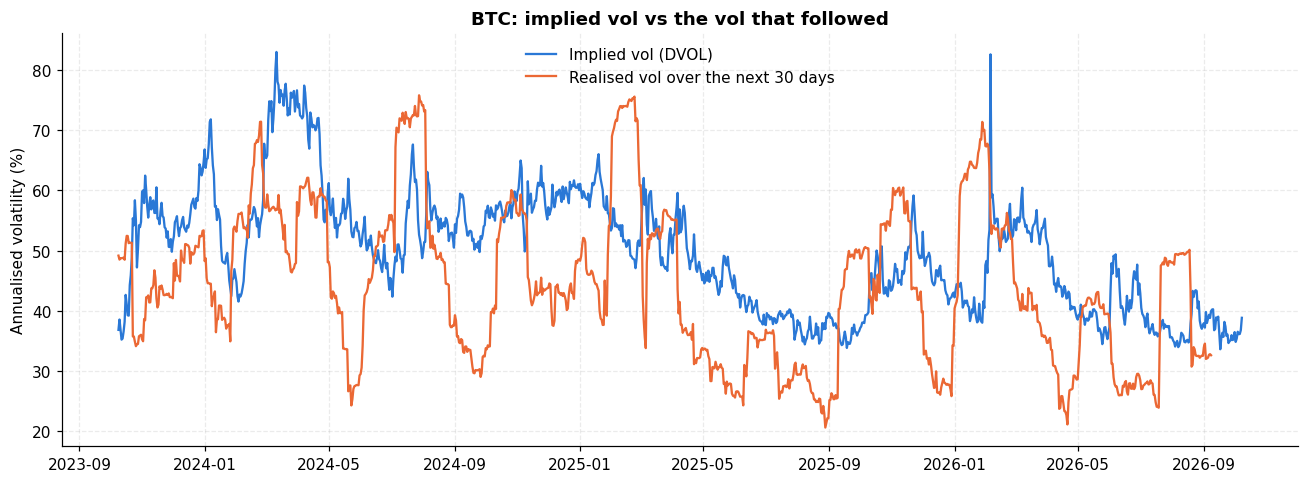

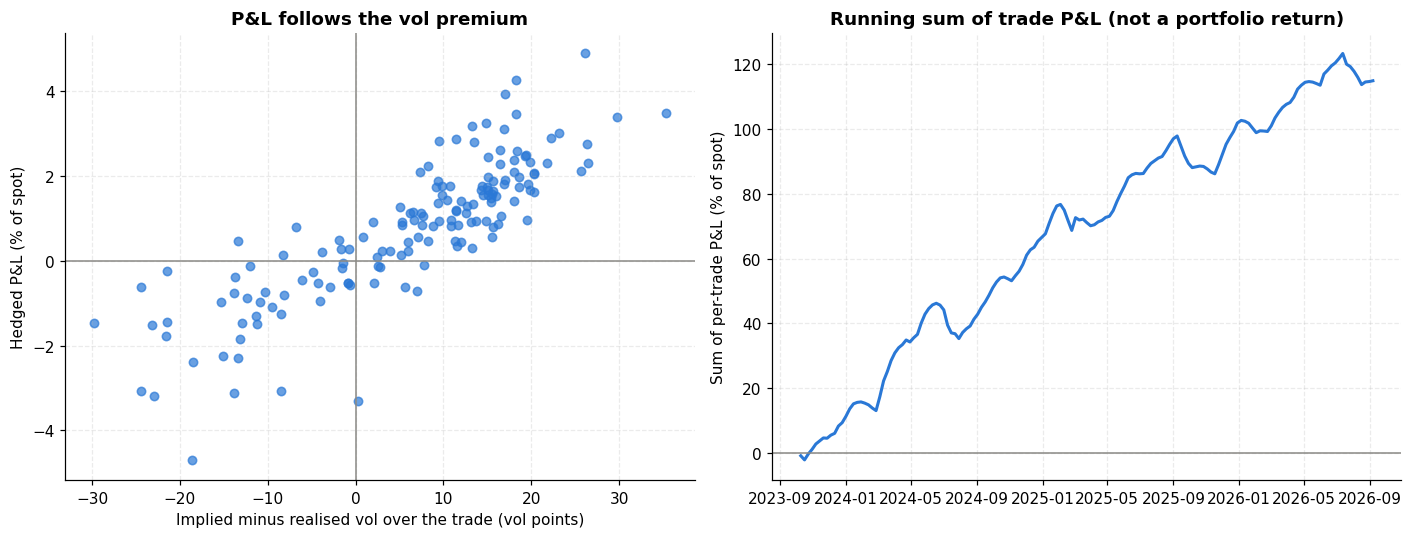

In [15]:
if btc is not None:
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(btc["date"], btc["dvol"], color=BLUE, linewidth=1.5, label="Implied vol (DVOL)")
    ax.plot(btc["date"], 100 * btc["rv_next_30d"], color=ORANGE, linewidth=1.5, label="Realised vol over the next 30 days")
    ax.set_ylabel("Annualised volatility (%)")
    ax.set_title("BTC: implied vol vs the vol that followed")
    ax.legend()
    plt.tight_layout(); plt.savefig("figures/06_btc_iv_vs_rv.png", bbox_inches="tight"); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ax = axes[0]
    ax.scatter(100 * trades["vol premium"], trades["P&L %"], s=30, color=BLUE, alpha=0.7)
    ax.axhline(0, color=GREY, linewidth=1); ax.axvline(0, color=GREY, linewidth=1)
    ax.set_xlabel("Implied minus realised vol over the trade (vol points)")
    ax.set_ylabel("Hedged P&L (% of spot)")
    ax.set_title("P&L follows the vol premium")
    ax = axes[1]
    ax.plot(trades["date"], trades["P&L %"].cumsum(), color=BLUE)
    ax.axhline(0, color=GREY, linewidth=1)
    ax.set_ylabel("Sum of per-trade P&L (% of spot)")
    ax.set_title("Running sum of trade P&L (not a portfolio return)")
    plt.tight_layout(); plt.savefig("figures/07_btc_backtest.png", bbox_inches="tight"); plt.show()

**What to look for in your results.**
- Is implied vol usually above realised vol? That gap is the **variance risk premium**: option sellers get paid for taking crash risk.
- Does the scatter slope upwards? It should, because the gamma identity says hedged P&L is driven by implied minus realised vol.
- **The running-sum chart is not a return.** Trades last 30 days but start every 7, so about four are open at once, and the P&Ls are added rather than compounded. Without a margin model there is no capital base to divide by.
- Compare the break-even spread with real Deribit ATM spreads.
- Look at the worst trades in the running-sum chart. Short-vol strategies tend to earn small steady gains and then give a chunk back in sharp moves. 

## 10. Summary


In [16]:
key_numbers = {
    "Hedging error slope vs N (theory -0.5)": round(slope, 3),
    "Derman-Kamal accuracy at daily-ish hedging (actual / theory)":
        round(freq.loc[freq["N hedges"] == 50, "actual / theory"].iloc[0], 3),
    "Corr(sim P&L, gamma formula), realised 30% vs implied 20%":
        round(mismatch.loc[mismatch["realised vol"] == 0.30, "corr(P&L, gamma formula)"].iloc[0], 4),
    "Optimal hedges over 3 months at 10bp": int(best_n.loc[best_n["cost (bp)"] == 10, "N hedges"].iloc[0]),
    "Mean P&L, BS pricing with 10bp costs": round(plain.mean(), 4),
    "Mean P&L, Leland pricing with 10bp costs": round(leland.mean(), 4),
    "  ...excluding set-up and unwind fees": round(leland.mean() + setup_unwind, 4),
}
if btc is not None:
    key_numbers["BTC trades backtested"] = len(trades)
    key_numbers["BTC average vol premium (vol points)"] = round(100 * trades["vol premium"].mean(), 2)
    key_numbers["BTC average hedged P&L (% of spot)"] = round(trades["P&L %"].mean(), 3)
    key_numbers["  ...after selling 1 vol point below mid"] = round(
        spread_table.loc[spread_table["vol pts below mid"] == 1, "avg P&L %"].iloc[0], 3)
    key_numbers["BTC break-even spread (vol points below mid)"] = round(breakeven, 1)
for k, v in key_numbers.items():
    print(f"{k:<65} {v}")

Hedging error slope vs N (theory -0.5)                            -0.487
Derman-Kamal accuracy at daily-ish hedging (actual / theory)      0.972
Corr(sim P&L, gamma formula), realised 30% vs implied 20%         0.984
Optimal hedges over 3 months at 10bp                              100
Mean P&L, BS pricing with 10bp costs                              -0.3544
Mean P&L, Leland pricing with 10bp costs                          -0.1016
  ...excluding set-up and unwind fees                             0.0021
BTC trades backtested                                             153
BTC average vol premium (vol points)                              6.05
BTC average hedged P&L (% of spot)                                0.751
  ...after selling 1 vol point below mid                          0.637
BTC break-even spread (vol points below mid)                      6.6
